### General

In [ ]:
import re
import pandas as pd

In [ ]:
def get_index_list(index_str):
    # NB: if title ends with numbers, it will be stripped of them
    return [i.rstrip('0123456789 ') for i in index_str.split('\n') if i != '' \
            and not i.startswith('Նկար՝')]

In [ ]:
def get_year_metadata(text):
  # try to get date when text written
  try:
      return re.search(r'(\d{4})-? ?թ(իվ)?\.? ?\n', text[-100:]).groups(1)[0]
  except:
      return ''

In [ ]:
def extract_fragments(text, index, genre, source):

    titles = get_index_list(index[genre])
    print(f'Declared titles: {len(titles)}')

    title_positions = []
    for title in titles:
        matched_title = re.search(re.escape(title), text)
        if matched_title:
            title_positions.append((title, matched_title.span()))
        else:
            print(f'This title is not found: {title}')

    title_positions.sort(key=lambda x: x[1][0]) # just in case

    ## debug mode
    # print(f'Title positions:')
    # print([(i[0], i[1][0]) for i in title_positions])

    fragments_list = []
    for i in range(len(title_positions) - 1): # the last title is only boundary
        fragments_list.append({
            'title': text[title_positions[i][1][0]:title_positions[i][1][1]],
            'text': text[title_positions[i][1][0]:title_positions[i + 1][1][0]]
        })
    print(f'Number of fragments found: {len(fragments_list)}')
    if [i[0] for i in title_positions] != titles:
        print('The order of found fragments is wrong')

    # remove short fragments
    fragments_list = [f for f in fragments_list if len(f['text']) >= 200]
    print(f'Total fragments after filter: {len(fragments_list)}')

    # add metadata
    for d in fragments_list:
        d['date'] = (get_year_metadata(d['text']))
        d['source'] = source
        d['genre'] = genre

    return  fragments_list

In [ ]:
texts_list = []

## a loop works fine only when you are sure of the texts
## for future development, older code
# for k, v in index_d.items():
#     texts_list.extend(extract_fragments(raw_text, v))
#     print()
# print(len(texts_list))

### Atamanyan file 1

In [ ]:
filename = 'Atamanyan1_copied_from_decoded_docx_converted_from_pdf.txt'
with open(filename, encoding='utf8') as f:
    raw_text = f.read()
print(len(raw_text))
print(raw_text[:100])

246787
ՍՈՒՐԵՆ ԱՏԱՄԱՆՅԱՆ 

ՄԵՐ ԿՅԱՆՔԻՑ 

Издательство «Терра-принт» 
г. Ростов-на-Дону 
2006 год 

Ատամանյան


Manually add index as string

In [ ]:
index_d = {}

# Բանաստեղծություններ

index_d['poem'] = '''
ԴՊՐՈՑԻ ՃԱՆՓԱՆ 09
ՄԵՐ «ԸՆԿԵՐԸ» 10
ՄԵՐ ԽԱՄՈՒԹԻ ՃԱՆՓԱՆ 11
ՄԱՇԻՆԸ 13
ԹՈՓՏԻՆ ԵՎ ԹՈՓՑԻԿԸ 15
ՕՀԱՆԸ 17
«ՔԱՋԸ» 19
ԴԻԲՈՆՋԻ ՅԱՆԳԱՆ 21
ՀՈՅՐՍ 23
Նկար՝ Սարգիս Ատամանյան 25
Նկար՝ Փառքի Պանթեոնը: 26
ՀՈՒՇԱՐՁԱՆԸ 27
ՓԱՌՔԻ ՊԱՆԹԵՈՆԸ 28
ԸՆՏՐՈՒԹՅՈՒՆՆԵՐԻՑ ԱՌԱՋ 29
ՈՒ՞Ր ՄՆԱՑ ՄԱՏԱՂ ԿՅԱՆՔՍ 30
«ԿՏՐԻՃՆԵՐ» 31
ՄԵՐ ԳԵՂԻ ԴԵՐԱՆ 33
ՄԵՐ ՀՈՐԱՔՈՒՅՐ ԶԱՐԴԱՐԸ 35
Պատմվածքներ
'''

index_d['story'] = '''
ՄԵՐ ԹՈՓՏԻ ԳԵՂԻ ԲԵՐԲԵՐՆԵՐԸ 39
ԲԵՐԲԵՐ ՎԱՇԴԱՆԻՆ ՊԱՏՄԱԾՆԵՐԻՑ 39
ՏԱՔ ՀԱՑԸ ՓՈԽ Է 42
ԱԿՈԲ ԲԱԲԻԻՆ ՏՈՒՆԸ ԾԱԽԱԾԸ 44

ՍՈՒՏ ՀԻՎԱՆԴԸ ԽԱՄՉԻՆ ԿԵՐԱՎ 47
ՄԱՆՅԵԼ ԵԳՈՌԻՉԸ ԵՎ ԲԵՐԲԵՐՆԵՐԸ 49
ԱՆՔԱՂԱՔԱՎԱՐՈՒԹՅԱՆ ՎՆԱՍՆԵՐ 54
ՊԱՏՄՈՒԹՅՈՒՆ ՆԻՍՎԻՏԱ ԳՅՈՒՂԻՑ 57
ԻՆՉԻ՞ ՉՈՓԼՈՒԿ ԿԳՈՅԱՑՈՒՆՈՒՆՔ 59
ՄԵԾ ՊԱՏԻՎԻ ԳԱՂՏՆԻՔԸ 61
ՏՈՒՆ ՓԵՍԱ ԷՇՏԱԼ ՉՈՒԶԱՑ 64
ԲՌՆԸՎԱԾ ՉԷ՝ ԳՈՂ ՉԷ 66
ԱՆՉԱՓ ԽՄԻՉՔԻ ՀԵՏԵՎԱՆՔԸ 68
Նկար՝ «Պըլ-Պուղի» պիեսայի ներկայացումից հետո 71
Նկար՝ Շիրվանզադեի «ՆԱՄՈՒՍ» պիեսում 72
ՇՈՂԱԿԻՆ ՀԵՏ ՊԱՏԱՀԱԾ ԴԵՊՔ 73
ՀՈՐԱՔՈՒՅՐՍ 75
ՔԱԽՑԱԾԻՆ ՏԱՐՎԱՆ ԶԵՆԿԻՆԻՆ ԽԻՂՃԸ 79
ՄԵՐ ՇՐՋԱՆԻ ՀԱՅԵՐԸ ՂՐԻՄԻ ԳԱՂՈՒԹԻՑ ՀԵՏՈ 83
ՄԱՅՐԵՆԻ ԼԵԶՎԻ ՄԱՍԻՆ 88
ԻՄ ՀՈՒՇԵՐԸ ԹՈՓՏԻ ԳՅՈՒՂԻ ԴՊՐՈՑՆԵՐԻ ՄԱՍԻՆ 91
ՊԱՏԵՐԱԶՄԻ ՏԱՐԻՆԵՐԻՆ 93
Նկար՝ Ս. Ատամանյանը առաջին դասարանում: 95
Նկար՝ Դպրոց № 6: Հին շենքը: 96
Նկար՝ Դպրոց № 5: Հին շենքը: 97
Նկար՝ Դպրոց № 5: Նոր շենքը: 98
ՊԱՏԵՐԱԶՄԻՑ ՀԵՏՈ 99

ՀԱՅՐԵՆԱԿԱՆ ՄԵԾ ՊԱՏԵՐԱԶՄԻ, ՀԱՂԹԱՆԱԿԻ 30-ՈՒՆ ԱՄՅԱԿԻ ԱՌԹԻՎ ՏԱՐԱԾ ԱՇԽԱՏԱՆՔՆԵՐԻՍ ՄԱՍԻՆ

ՈՉ ՈՔ ՉԻ ՄՈՌԱՑՎԵԼ, ՈՉԻՆՉ ՉԻ ՄՈՌԱՑՎԵԼ

ԱՍԼԱՆ ԲԵԿԸ

ԹԻԼՔԻՆ ԵՎ ՔԵԼԼՈՆ (Հեքյաթ)

Նկար՝ «Պըլ-Պուղի» պիեսայի ներկայացումից հետո
Նկար՝ Հանդիպում Հայաստանի գրողների հետ

ԽԱՄՉԻՆ (Հեքյաթ)

ՄԱՆՅԵԼ ԵԳՈՌԻՉԻՆ ՀՈՒՇԵՐԻՑ

ՍՐԱԲԻՈՆ (ՑՅԱԲՈՆ) ԲԱԲԻՆ

ԱԲԻՆԸ 150
ՄԵՐ ՄԵԾԱՆԵՐԸ. ՎԱՌՈՒՇԸ, ՄԱԽՏԱՐԸ, ՍՈՒՐԲՈՒԻՆԸ ԵՎ ՄԱՆՅԱՆ ԱՌԱՉՎԱՆ ԺԱՄԱՆԱԿՆԵՐՈՒՆ 154
ՎԱՌՈՒՇ ԵՎ ՄԱԽՏԱՐ ՄԵԾԱՆԵՐՈՒՍ ԹԻԹՈՒՆ ԾԱԽԱԾՆԵՐԸ 156

ՄԵՐ ՄՈՐԱՔՈՒՅՐ ՅԵՎԿԻՆԵՆ
ՆԻԿՈՂՈՍ ՕՇՏԱԽԻՍ ԴԱՐԴԵՐԸ
ՇՏԵ ՔԵԶԻ ՉԱՓԵՆ ԱՆՑՆԵԼ
ՓՈՐՑԱՆՔԻ ՄԵՉ ՄԻ ՑՔԻՔ
Նկար՝ Ս. Ատամանյանը շրջանի հայասերների հետ Նկար՝ Գրական ստուդիաի անդամների հետ
ՊԱՏԻՎ ԿՈՒՏԱՆ ՆԸ, ՊԱՏԻՎԸԴ ԳԻՏՑԻՐ
«ՔԱՋ» ԲԱՐԵԿԱՄԻՍ ԴԱՍ ԷՂԱՎ

ԳԱՊՌԵԼԻՆ ՃԱՐԸ 183

ՄԵՐ ԳԵՂԻ ՇԱԽԱՋԻՆԵՐԸ

ՋԱՂԱՉՔԻ ՀՐԱՇՔՆԵՐ

ԽԱՌԱՄԱՆԻՆ ՔՇԿՈՐԸ 195

ԱՉՔԵ ՏԵՍ, ԻՆՔԵՐՍ ԿԱՐՈՏ

ԽՄԻՉՔԻ ՀԱՎԵՍ ՄԱՐԴԻՔ

ԲՌԻԼԸ

ԱՍՏԸՂԻՆ ՀԻՎԱՆՏԵՍ ԳՆԱՑԱԾԸ

ՄԵԾ ՍԱԼԱՑԻԿ ԵՎ ՆԻՍԹԱՑԻԿ 205

ԲԱՌԱՐԱՆ ՉԱԼԹՐՑՈՑ ԵՎ ԹՈՓՑՈՑ
'''

In [ ]:
get_index_list(index_d['poem'])

['ԴՊՐՈՑԻ ՃԱՆՓԱՆ',
 'ՄԵՐ «ԸՆԿԵՐԸ»',
 'ՄԵՐ ԽԱՄՈՒԹԻ ՃԱՆՓԱՆ',
 'ՄԱՇԻՆԸ',
 'ԹՈՓՏԻՆ ԵՎ ԹՈՓՑԻԿԸ',
 'ՕՀԱՆԸ',
 '«ՔԱՋԸ»',
 'ԴԻԲՈՆՋԻ ՅԱՆԳԱՆ',
 'ՀՈՅՐՍ',
 'ՀՈՒՇԱՐՁԱՆԸ',
 'ՓԱՌՔԻ ՊԱՆԹԵՈՆԸ',
 'ԸՆՏՐՈՒԹՅՈՒՆՆԵՐԻՑ ԱՌԱՋ',
 'ՈՒ՞Ր ՄՆԱՑ ՄԱՏԱՂ ԿՅԱՆՔՍ',
 '«ԿՏՐԻՃՆԵՐ»',
 'ՄԵՐ ԳԵՂԻ ԴԵՐԱՆ',
 'ՄԵՐ ՀՈՐԱՔՈՒՅՐ ԶԱՐԴԱՐԸ',
 'Պատմվածքներ']

In [ ]:
texts_list.extend(extract_fragments(raw_text, index_d, 'poem', 'Atamanyan_2006'))
print(len(texts_list))

Declared titles: 17
Number of fragments found: 16
Total fragments after filter: 16
16


In [ ]:
get_index_list(index_d['story'])

['ՄԵՐ ԹՈՓՏԻ ԳԵՂԻ ԲԵՐԲԵՐՆԵՐԸ',
 'ԲԵՐԲԵՐ ՎԱՇԴԱՆԻՆ ՊԱՏՄԱԾՆԵՐԻՑ',
 'ՏԱՔ ՀԱՑԸ ՓՈԽ Է',
 'ԱԿՈԲ ԲԱԲԻԻՆ ՏՈՒՆԸ ԾԱԽԱԾԸ',
 'ՍՈՒՏ ՀԻՎԱՆԴԸ ԽԱՄՉԻՆ ԿԵՐԱՎ',
 'ՄԱՆՅԵԼ ԵԳՈՌԻՉԸ ԵՎ ԲԵՐԲԵՐՆԵՐԸ',
 'ԱՆՔԱՂԱՔԱՎԱՐՈՒԹՅԱՆ ՎՆԱՍՆԵՐ',
 'ՊԱՏՄՈՒԹՅՈՒՆ ՆԻՍՎԻՏԱ ԳՅՈՒՂԻՑ',
 'ԻՆՉԻ՞ ՉՈՓԼՈՒԿ ԿԳՈՅԱՑՈՒՆՈՒՆՔ',
 'ՄԵԾ ՊԱՏԻՎԻ ԳԱՂՏՆԻՔԸ',
 'ՏՈՒՆ ՓԵՍԱ ԷՇՏԱԼ ՉՈՒԶԱՑ',
 'ԲՌՆԸՎԱԾ ՉԷ՝ ԳՈՂ ՉԷ',
 'ԱՆՉԱՓ ԽՄԻՉՔԻ ՀԵՏԵՎԱՆՔԸ',
 'ՇՈՂԱԿԻՆ ՀԵՏ ՊԱՏԱՀԱԾ ԴԵՊՔ',
 'ՀՈՐԱՔՈՒՅՐՍ',
 'ՔԱԽՑԱԾԻՆ ՏԱՐՎԱՆ ԶԵՆԿԻՆԻՆ ԽԻՂՃԸ',
 'ՄԵՐ ՇՐՋԱՆԻ ՀԱՅԵՐԸ ՂՐԻՄԻ ԳԱՂՈՒԹԻՑ ՀԵՏՈ',
 'ՄԱՅՐԵՆԻ ԼԵԶՎԻ ՄԱՍԻՆ',
 'ԻՄ ՀՈՒՇԵՐԸ ԹՈՓՏԻ ԳՅՈՒՂԻ ԴՊՐՈՑՆԵՐԻ ՄԱՍԻՆ',
 'ՊԱՏԵՐԱԶՄԻ ՏԱՐԻՆԵՐԻՆ',
 'ՊԱՏԵՐԱԶՄԻՑ ՀԵՏՈ',
 'ՀԱՅՐԵՆԱԿԱՆ ՄԵԾ ՊԱՏԵՐԱԶՄԻ, ՀԱՂԹԱՆԱԿԻ 30-ՈՒՆ ԱՄՅԱԿԻ ԱՌԹԻՎ ՏԱՐԱԾ ԱՇԽԱՏԱՆՔՆԵՐԻՍ ՄԱՍԻՆ',
 'ՈՉ ՈՔ ՉԻ ՄՈՌԱՑՎԵԼ, ՈՉԻՆՉ ՉԻ ՄՈՌԱՑՎԵԼ',
 'ԱՍԼԱՆ ԲԵԿԸ',
 'ԹԻԼՔԻՆ ԵՎ ՔԵԼԼՈՆ (Հեքյաթ)',
 'ԽԱՄՉԻՆ (Հեքյաթ)',
 'ՄԱՆՅԵԼ ԵԳՈՌԻՉԻՆ ՀՈՒՇԵՐԻՑ',
 'ՍՐԱԲԻՈՆ (ՑՅԱԲՈՆ) ԲԱԲԻՆ',
 'ԱԲԻՆԸ',
 'ՄԵՐ ՄԵԾԱՆԵՐԸ. ՎԱՌՈՒՇԸ, ՄԱԽՏԱՐԸ, ՍՈՒՐԲՈՒԻՆԸ ԵՎ ՄԱՆՅԱՆ ԱՌԱՉՎԱՆ ԺԱՄԱՆԱԿՆԵՐՈՒՆ',
 'ՎԱՌՈՒՇ ԵՎ ՄԱԽՏԱՐ ՄԵԾԱՆԵՐՈՒՍ ԹԻԹՈՒՆ ԾԱԽԱԾՆԵՐԸ',
 'ՄԵՐ ՄՈՐԱՔՈՒ

In [ ]:
texts_list.extend(extract_fragments(raw_text, index_d, 'story', 'Atamanyan_2006'))
print(len(texts_list))

Declared titles: 47
Number of fragments found: 46
Total fragments after filter: 46
62


### Atamanyan file 2

In [ ]:
filename = 'Atamanyan2_copied_from_decoded_docx_converted_from_pdf.txt'
with open(filename, encoding='utf8') as f:
    raw_text = f.read()
print(len(raw_text))
print(raw_text[:100])

227831
Ատամանյան Ս. 
ՄԵՐ ԿՅԱՆՔԻՑ: Գիրք երկրորդ: - Ռոստով-նա-Դոնու: 2012 թ. 304 էջ: Атаманян С. С. 
ИЗ НАШЕЙ


Manually add index as string

In [ ]:
index_d = {}

# Բանաստեղծություններ

index_d['poem'] = '''
ԹՈՓՏԻՆ ԵՎ ԹՈՓՑԻԿԸ 09
Նկար՝ Եկեղեցին մեր «Ամենափրկիչ» 11
Նկար՝ Մեր «Մեծ չորվախը» նոր տեսքով 12
ՄԵՐ ՄԵԾ ՉՈՐՎԱԽԸ 13
ՄԱՅՐԻԿԻՍ 14
Նկար՝ ՀՌԻՓՍԻՄԵ ՎԱՐԴԱՆԻ ԱՏԱՄԱՆՅԱՆ 15
Նկար՝ Գեվորգ Ռուբենի Լյուլեճյան 16
ՍՈՒՐԵՆ ԵՂԲԱՅՐ 17
ԳԵՎՈՐԳ ԼՅՈՒԼԵՃՅԱՆԻ 85-ԱՄՅԱԿԻՆ 18
Նկար՝ Գեվորգ Լյուլեճյան, Սուրեն Ատամանյան 19
Նկար՝Ասվատուր Դաղլդիյան 20
ԱՍՎԱՏՈՒՐ ԸՆԿԵՐՈՋՍ 80-ԱՄՅԱԿԻՆ ԱՌԹԻՎ 21
ԹՈՓՏԻՅԻ ԿԱՍՍԵՐԸ 23

Պատմվածքներ
'''

index_d['story'] = '''
Նկար՝ Հեղինակը աշխատանքի ժամանակ 26
ՄԵՐ ԽԱՉԵԽՊԱՐ ՀԵՔԻՄԸ 27
Նկար՝ Խաչեխպար Կարապետի Սողոմոնյանը 29

ԲԱԴԱՍ ԱՂԱՆ 31
ԽՈՒՆԿՅԱՆՈՍ ԲԱԲԻՆ 35
Նկար՝ Խունկյանոս Խալամբաշյան 37
ԻՍԿԱԿԱՆ ՀԵՔԻՄՆԵՐԸ ԱԴՊԵՍ ՊԱՐՏ ԻՆ ԸԼԱԼ 40
Նկար՝ Լուսեղեն Մովսեսյան, Թամարա Մովսեսյան 42
Նկար՝ Եվգինե Քառտաշյան (Սուխառիյան) 46
ՄԵՐ ԳԵՂԻ ԿՈՒՌԱՇԻ ՀԱՎԵՍ ՄԱՇԴԻՔ 47
Նկար՝ Համբարձում Խանթեմերյան 49
ԹՈՓՏԻԻ ՉՈՐՎԱԽՆԵՐԸ 51
Նկար՝ Մեծ չորվախի հին տեսքը 53
Նկար՝ Մեծ չորվախը նոր տեսքով 54
Նկար՝ Բային չորվախը նոր տեսքով 57
Նկար՝ Ջըլ-ջ ըլ չորվախը հինութվան տեսքով 59
ԹՈՓՏԻԻ ԵՐԳԻՉՆԵՐԸ 60
Նկար՝ Թոփտիի երգիչների և նվագողների խումբը 61
ՄԵՐ ՇՐՋԱՆԻ «ՋԱՂԱՉՔՆԵՐԸ» ՎԱԼԾՈՎԿԱՆԵՐԸ 67
Նկար՝ Ասվատուր Չուբարյանը 69
ԲԱՐԱԲ ԱԶԲԱՐԸ 75
ԲԱՐԵՍԻՐՏ ՍՈՒՔԻԱՍԸ 80
ՄԻ ԿՅԱՆՔԻ ՊԱՏՄՈՒԹՅՈՒՆ 85
Նկար՝ Գրիգորը իր կնոջ Թագուհու հետ 87
ՓԻԼԱ ՄԵԾԱՅԻՆ ԴԱՍԵՐԸ 91
ԽԱՉԵՐԵՍ ՕՇՏԱԽԻՍ ԴԱՎՈՒԼԸ 94
Նկար՝ Խաչերես օշտախըս իրեն դավուլով 95
ՏԱՇԿԵՆՏԻ ՀԱՐՍԱՆԻՔ ՉԱԼԱԾՆԵՐԸՍ 104
Նկար՝ Կարապետ Անդոնյան 105
ԹՈՓՏԻԻ ԲԱՂՏԻԿՆԵՐԸ 117

Նկար՝ Թեվաթոս Բայանը - Թեվա աղան 119

 Հումորներ
'''

index_d['comedy'] = '''
Նկար՝Աքսենդ Բայան և ՍուրեՆ Ատամանյան 124
ԹԻԼՔԻՆ ԳՈՄԵՍԻ ԽԱՌԱՎՈՒԼ 125
ՍԵՐՈՎ ՊԱՆԻՐ ԿԸ ՍԻՐԵՐ 131
ՑՅԱԲՈՅԻՆ ՀԵՏ ԱՐԱԾ ԳԱԼԱՋԻՆԵՐԸՍ 135
ՄԻՏՔ ՉԱՆԵԼԵ ԳԱԼԱՋԻՆԵՐ ԵՎ ԿԱՄ ՍԿԼԵՌՈԶ 139
Նկար՝Շեն, շախաջի հորքուրներըս 142
Նկար՝Ղունկին և Արդավազդ շախաջի օշտախներըս 146
ԽԱԲԵԼՈՒՅԻՆ ՀԵՏԵՎԱՆՔԸ 148
ՄԸԿՐԻՆ ՕՎԱՆԵՍԸ 152
Նկար՝Օվանես բաբին 154
ՀԱՐՍՆԱՌԸ 157
ԹԵՓՈՏԻՆ ԼՈՒԿԱՅԻՆ ՇԱԽԱՆԵՐԸ 162
Նկար՝Լուսեղեն Մայկողլույան 170
ԻՄ ՀՈՒՇԵՐԻՑ ՄԵԿԸ 176
Նկար՝Սուրեն Ատամանյան, Լուսեղեն Բերեքչիյան 177
ՀԱՆԴԻՊՈՒՄ 183

Ֆելիետոններ
'''

index_d['feuilleton'] = '''
ԽՄԻՉՔԻ ՀԱՎԵՍ ՄԱՇԴԻՔ 189
ԱՆՄԱՀԱԿԱՆ ՋՈՒՐԸ 192
ՇՏԵ ՔԵԶԻ ԷԿՈԼՈԳԻԱ 197
ՏՈՌՂԱՅԸ 200
ՇՈՖԵՌԻ ԻՐԱՎՈՒ՞ՆՔ ՈՒՆԵՆԱԼ, ԹԵ՞ ԱԿԱԴԵՄԻԱՅԻ ԴԻՊԼՈՄԸ 203

ՇՈՒՆԸ ՏԵՐՈՉԸ ՃԱՆՉՑԱԾ ՉԷ 207
Նկար՝Ակոփ Ղուկասի Ակոփյան 209
ԶՐՈՒՅՑՆԵՐ 212
Նկար՝Թոփտի գեղի տարուքով մաշդիք 214
ԿԵՆԵ ՄԵՐ ՀԱՐՍՆԻՔՆԵՐՈՒՆ ՄԱՍԻՆ 215
ԶԱԳՍԻ ՕՃԵՌԵԴԸ 218
«ՏԸ ԲԸ»-ԻՆ ԼՈՒԿԱՆ 220
ՄԵԿ ՏԱՆՋԱՆՔԻ ՊԱՏՄՈՒԹՅՈՒՆ 225

Հեքիաթներ
'''

index_d['tale'] = '''
ԽԱԶԻՆ ՉՈՅԻՆԵՆ ՀԱՆԱԾԸ, ՏԵՂԸ ՉԱՌՈԽՆԵՐԸ ՑԸՔԱԾԸ 231
ՊԻԼՅՈՒԼԻԱՆ 236
ՁԻՅԻՆ ՊՈՉԸ 241
ՍԱՏԱՆԱՅԻՆ ՍԱԹԱՅԵԼԸ 246
ՏԵԼԱԼԸ 252
Ի՛ՆՉ ԿՆՇԱՆԱԿԵ ԻՍՏԻՐ ԵՂԲԱՅՐԸ 257
Նկար՝Ասվատուր Օլանյան 257
ԱՍՎԱՏՈՒՐ ԱՂԱՅԻՆ ՊԱՏՄԱԾԸ 258
Նկար՝ Մանուկ Փեհլիվանյան 262
ՄԱՆՈՒԿ ԲԱՐԵԿԱՄԻՍ ՊԱՏՄԱԾԸ 262
Նկար՝ Վաշտան Խուլայան 265
ՎԱՇՏԱՆ ԲԱՐԵԿԱՄԻՍ ՊԱՏՄԱԾԸ 265
'''

In [ ]:
get_index_list(index_d['poem'])

['ԹՈՓՏԻՆ ԵՎ ԹՈՓՑԻԿԸ',
 'ՄԵՐ ՄԵԾ ՉՈՐՎԱԽԸ',
 'ՄԱՅՐԻԿԻՍ',
 'ՍՈՒՐԵՆ ԵՂԲԱՅՐ',
 'ԳԵՎՈՐԳ ԼՅՈՒԼԵՃՅԱՆԻ 85-ԱՄՅԱԿԻՆ',
 'ԱՍՎԱՏՈՒՐ ԸՆԿԵՐՈՋՍ 80-ԱՄՅԱԿԻՆ ԱՌԹԻՎ',
 'ԹՈՓՏԻՅԻ ԿԱՍՍԵՐԸ',
 'Պատմվածքներ']

In [ ]:
texts_list.extend(extract_fragments(raw_text, index_d, 'poem', 'Atamanyan_2012'))
print(len(texts_list))

Declared titles: 8
Number of fragments found: 7
Total fragments after filter: 7
69


In [ ]:
get_index_list(index_d['story'])

['ՄԵՐ ԽԱՉԵԽՊԱՐ ՀԵՔԻՄԸ',
 'ԲԱԴԱՍ ԱՂԱՆ',
 'ԽՈՒՆԿՅԱՆՈՍ ԲԱԲԻՆ',
 'ԻՍԿԱԿԱՆ ՀԵՔԻՄՆԵՐԸ ԱԴՊԵՍ ՊԱՐՏ ԻՆ ԸԼԱԼ',
 'ՄԵՐ ԳԵՂԻ ԿՈՒՌԱՇԻ ՀԱՎԵՍ ՄԱՇԴԻՔ',
 'ԹՈՓՏԻԻ ՉՈՐՎԱԽՆԵՐԸ',
 'ԹՈՓՏԻԻ ԵՐԳԻՉՆԵՐԸ',
 'ՄԵՐ ՇՐՋԱՆԻ «ՋԱՂԱՉՔՆԵՐԸ» ՎԱԼԾՈՎԿԱՆԵՐԸ',
 'ԲԱՐԱԲ ԱԶԲԱՐԸ',
 'ԲԱՐԵՍԻՐՏ ՍՈՒՔԻԱՍԸ',
 'ՄԻ ԿՅԱՆՔԻ ՊԱՏՄՈՒԹՅՈՒՆ',
 'ՓԻԼԱ ՄԵԾԱՅԻՆ ԴԱՍԵՐԸ',
 'ԽԱՉԵՐԵՍ ՕՇՏԱԽԻՍ ԴԱՎՈՒԼԸ',
 'ՏԱՇԿԵՆՏԻ ՀԱՐՍԱՆԻՔ ՉԱԼԱԾՆԵՐԸՍ',
 'ԹՈՓՏԻԻ ԲԱՂՏԻԿՆԵՐԸ',
 ' Հումորներ']

In [ ]:
texts_list.extend(extract_fragments(raw_text, index_d, 'story', 'Atamanyan_2012'))
print(len(texts_list))

Declared titles: 16
Number of fragments found: 15
Total fragments after filter: 15
84


In [ ]:
get_index_list(index_d['comedy'])

['ԹԻԼՔԻՆ ԳՈՄԵՍԻ ԽԱՌԱՎՈՒԼ',
 'ՍԵՐՈՎ ՊԱՆԻՐ ԿԸ ՍԻՐԵՐ',
 'ՑՅԱԲՈՅԻՆ ՀԵՏ ԱՐԱԾ ԳԱԼԱՋԻՆԵՐԸՍ',
 'ՄԻՏՔ ՉԱՆԵԼԵ ԳԱԼԱՋԻՆԵՐ ԵՎ ԿԱՄ ՍԿԼԵՌՈԶ',
 'ԽԱԲԵԼՈՒՅԻՆ ՀԵՏԵՎԱՆՔԸ',
 'ՄԸԿՐԻՆ ՕՎԱՆԵՍԸ',
 'ՀԱՐՍՆԱՌԸ',
 'ԹԵՓՈՏԻՆ ԼՈՒԿԱՅԻՆ ՇԱԽԱՆԵՐԸ',
 'ԻՄ ՀՈՒՇԵՐԻՑ ՄԵԿԸ',
 'ՀԱՆԴԻՊՈՒՄ',
 'Ֆելիետոններ']

In [ ]:
texts_list.extend(extract_fragments(raw_text, index_d, 'comedy', 'Atamanyan_2012'))
print(len(texts_list))

Declared titles: 11
Number of fragments found: 10
Total fragments after filter: 10
94


In [ ]:
get_index_list(index_d['feuilleton'])

['ԽՄԻՉՔԻ ՀԱՎԵՍ ՄԱՇԴԻՔ',
 'ԱՆՄԱՀԱԿԱՆ ՋՈՒՐԸ',
 'ՇՏԵ ՔԵԶԻ ԷԿՈԼՈԳԻԱ',
 'ՏՈՌՂԱՅԸ',
 'ՇՈՖԵՌԻ ԻՐԱՎՈՒ՞ՆՔ ՈՒՆԵՆԱԼ, ԹԵ՞ ԱԿԱԴԵՄԻԱՅԻ ԴԻՊԼՈՄԸ',
 'ՇՈՒՆԸ ՏԵՐՈՉԸ ՃԱՆՉՑԱԾ ՉԷ',
 'ԶՐՈՒՅՑՆԵՐ',
 'ԿԵՆԵ ՄԵՐ ՀԱՐՍՆԻՔՆԵՐՈՒՆ ՄԱՍԻՆ',
 'ԶԱԳՍԻ ՕՃԵՌԵԴԸ',
 '«ՏԸ ԲԸ»-ԻՆ ԼՈՒԿԱՆ',
 'ՄԵԿ ՏԱՆՋԱՆՔԻ ՊԱՏՄՈՒԹՅՈՒՆ',
 'Հեքիաթներ']

In [ ]:
texts_list.extend(extract_fragments(raw_text, index_d, 'feuilleton', 'Atamanyan_2012'))
print(len(texts_list))

Declared titles: 12
Number of fragments found: 11
Total fragments after filter: 11
105


In [ ]:
get_index_list(index_d['tale'])

['ԽԱԶԻՆ ՉՈՅԻՆԵՆ ՀԱՆԱԾԸ, ՏԵՂԸ ՉԱՌՈԽՆԵՐԸ ՑԸՔԱԾԸ',
 'ՊԻԼՅՈՒԼԻԱՆ',
 'ՁԻՅԻՆ ՊՈՉԸ',
 'ՍԱՏԱՆԱՅԻՆ ՍԱԹԱՅԵԼԸ',
 'ՏԵԼԱԼԸ',
 'Ի՛ՆՉ ԿՆՇԱՆԱԿԵ ԻՍՏԻՐ ԵՂԲԱՅՐԸ',
 'ԱՍՎԱՏՈՒՐ ԱՂԱՅԻՆ ՊԱՏՄԱԾԸ',
 'ՄԱՆՈՒԿ ԲԱՐԵԿԱՄԻՍ ՊԱՏՄԱԾԸ',
 'ՎԱՇՏԱՆ ԲԱՐԵԿԱՄԻՍ ՊԱՏՄԱԾԸ']

In [ ]:
texts_list.extend(extract_fragments(raw_text, index_d, 'tale', 'Atamanyan_2012'))
print(len(texts_list))

Declared titles: 9
Number of fragments found: 8
Total fragments after filter: 8
113


### Atamanyan file 3

In [ ]:
filename = 'Atamanyan3_copied_from_decoded_docx_converted_from_pdf.txt'
with open(filename, encoding='utf8') as f:
    raw_text = f.read()
print(len(raw_text))
print(raw_text[:100])

176214
Ատամանյան Ս. 
ՄԵՐ ԿՅԱՆՔԻՑ: Գիրք երրորդ: - Ռոստով-նա-Դոնու: 2017 թ. 224 էջ: Атаманян С. С. 
ИЗ НАШЕЙ 


Manually add index as string

In [ ]:
index_d = {}

# ԲԱՆԱՍՏԵՂԾՈՒԹՅՈՒՆՆԵՐ
index_d['poem']  = '''
Նկար՝ Հայոց լեզվի դասատու Ղ. Ճլավուխյան 06
ՀԱՅՈՑ ԼԵԶՎԻ ՊԱՀԱՊԱՆԸ 07
Նկար՝ Թոփտու միջնագարկ № 5 դպրոցի 7-րդ դասարանի աշակերտներ: 08
70 ՏԱՐԻ ԱՍԿԻՑ ԱՌԱՉ 09
Նկար՝ Հեռեփ, Զարթար, Վաշդուին, Վարսենիկ 14
ԿՆՈՋՍ 15
Նկար՝ Իմ կինը՝ Վարդուհին 16

ՊԱՏՄՎԱԾՔՆԵՐ
'''

index_d['story'] = '''
Նկար՝ Հեղինակը աշխատանքի ժամանակ 18
ՇՈՒՆԸ ՏԵՐՈՉԸ ՉԻ ՄՈՌՆԱ 19
ՍԵՄՅՈՆ ՏԱՌԱՍԻՉԸ - «ՍՅՈՄՔԱՆ» 24
Նկար՝ ՍԻՄՈՆ ԹՈՐՈՍԻ ԲԱՂԱԳՈԶՅԱՆ 29
ԻՆՉ ՔՑԱՆԻՍ, ԱՆ ԱԼ ԿՆՁԻՍ 30
ՄԵԿ ԽՄԻՉՔԻ ՄԱՍԻՆ 40
ՔԱՇԵԼԻՔՆ Է, ԹՈՂ ՔԱՇԵ 43
«ՁԿՆՈՐՍԸ» ՏՈՒՆԵՆ - ՏԵՂԵՆ ԶՐԿՎԵՑԱՎ 48
ՀԱՎԵՐԸ 55
ՄԵԿ ՓՈՔՐ ՄԵԽԴՐԱՆՔ 61
ՄԵՐ ԽՐԱՏԸ ՍԻԳԱՌ ՎԱՌՈՂՆԵՐՈՒՆ 67
ԱՉՔԸ ՄՈՒԹ ԿՈԽԱԾԻ ՀԵՏԵՎԱՆՔՆԵՐ 72
ՍԱՐՍԱՓԵԼԻ ԿԱԾԱԿԸ 78
ՊԱՏԵՐԱԶՄԻ ԺԱՄԱՆԱԿՎԱ ԹՈՓՏԻԻ ԵՐԵԽԱՆԵՐԸ 82
1. ԱՉՔՈՎ ՏԵՍ, ԲԵՐԱՆԵ ԿԱՐՈՏ 83
2. ՔԻՉԻՄ ԱԼ ՄԵՐ ԼԾԱԾ ԵԶԵՐՈՒՆ ՄԱՍԻՆ 84
Նկար՝ Սիբես եզերով ապրանք կկրեյինք, տաշով կանեինք: 87
3. ԱՉԱՌՆԵՐՈՒՆ ԼՈՒԾԻ ՍՈՐՎԵՑՈՒՑԱԾՆԵՐՍ 87
Նկար՝ Սիբես աչառներ էին լուծի սորվեցուցածներս: 90
4. ՍԵՌԸՅ ԲԱՅԹԱԼԸ ԻՆՁԻ ՓՐԿԻՑ 90
Նկար՝ Հանա սիբես տռնավուճով էր ջանգածս: 94
ՉՄՈՌԱՑՎԱԾ ՍԵՐ 95
ԱԲԳԱՐԻՆ ՀԵՏ ԱՐԱԾ ԶՐՈՒՅՑՆԵՐՍ 105
ԽՄԻՉՔԻ ՀԱՎԵՍ ՄԱՐԴԿԱՆՑ ՀԵՏԵՎԱՆՔԸ 111
ԹԵԼԵՖՈՆՈՎ ԳԱԼԱՋԻՆԵՐՈՒ ՀԵՏԵՎԱՆՔՆԵՐ 115
ՏՈՒՆ ՄԻ ԳՆԻ, ԴԻՐԱՑԻՆ ԳՆԵ 123
ԹԵՎԱԹՈՍԻՆ ՊԱՏՄԱԾԸ 127
ԹՈՓՑԻՅԻՆ ԽՈԶԻ ՊԱՏՄՈՒԹՈՒՆԸ 131
70 ՏԱՐԻ ԱՌԱՋ 135
1. ԲԻԶԸ ՉՈՒՎԱԼԸ ՊԱՀԵԼՈՒ ԲԱՆ ՉԷ 135
2. «ՄԵՆԿԱՅԻՆ» ՃԱՆՓԱՆ 138
ՀԻՆՈՒԹՎԱՆ ՊԱՏՄՈՒԹՅՈՒՆ 144
Նկար՝ Սա Վաշդան բաբիյիս ընտանիքն է: 150
ԻՄ ԱՇԽԱՏԱՆՔԸ Գ.ՋԱԼԱՇՅԱՆԻ 151

Նկար՝ Նոր Նախիջևանի բարբառի բացատրական բառարան 151
Նկար՝ Գ.Ջալաշյանը 152
Նկար՝ Գ. Ջալաշյանի ձեռագիրը 153
ԽՈՍՔ ՄԱՅՐԵՆԻ ԼԵԶՎԻ ՄԱՍԻՆ 155
Նկար՝ Ս. Ատամանյան 155

СТРАНИЦА ПЕРЕВОДА – ԹԱՐԳՄԱՆՈՒԹՅԱՆ ԷՋ
'''

In [ ]:
get_index_list(index_d['poem'])

['ՀԱՅՈՑ ԼԵԶՎԻ ՊԱՀԱՊԱՆԸ', '70 ՏԱՐԻ ԱՍԿԻՑ ԱՌԱՉ', 'ԿՆՈՋՍ', 'ՊԱՏՄՎԱԾՔՆԵՐ']

In [ ]:
texts_list.extend(extract_fragments(raw_text, index_d, 'poem', 'Atamanyan_2017'))
print(len(texts_list))

Declared titles: 4
Number of fragments found: 3
Total fragments after filter: 3
116


In [ ]:
get_index_list(index_d['story'])

['ՇՈՒՆԸ ՏԵՐՈՉԸ ՉԻ ՄՈՌՆԱ',
 'ՍԵՄՅՈՆ ՏԱՌԱՍԻՉԸ - «ՍՅՈՄՔԱՆ»',
 'ԻՆՉ ՔՑԱՆԻՍ, ԱՆ ԱԼ ԿՆՁԻՍ',
 'ՄԵԿ ԽՄԻՉՔԻ ՄԱՍԻՆ',
 'ՔԱՇԵԼԻՔՆ Է, ԹՈՂ ՔԱՇԵ',
 '«ՁԿՆՈՐՍԸ» ՏՈՒՆԵՆ - ՏԵՂԵՆ ԶՐԿՎԵՑԱՎ',
 'ՀԱՎԵՐԸ',
 'ՄԵԿ ՓՈՔՐ ՄԵԽԴՐԱՆՔ',
 'ՄԵՐ ԽՐԱՏԸ ՍԻԳԱՌ ՎԱՌՈՂՆԵՐՈՒՆ',
 'ԱՉՔԸ ՄՈՒԹ ԿՈԽԱԾԻ ՀԵՏԵՎԱՆՔՆԵՐ',
 'ՍԱՐՍԱՓԵԼԻ ԿԱԾԱԿԸ',
 'ՊԱՏԵՐԱԶՄԻ ԺԱՄԱՆԱԿՎԱ ԹՈՓՏԻԻ ԵՐԵԽԱՆԵՐԸ',
 '1. ԱՉՔՈՎ ՏԵՍ, ԲԵՐԱՆԵ ԿԱՐՈՏ',
 '2. ՔԻՉԻՄ ԱԼ ՄԵՐ ԼԾԱԾ ԵԶԵՐՈՒՆ ՄԱՍԻՆ',
 '3. ԱՉԱՌՆԵՐՈՒՆ ԼՈՒԾԻ ՍՈՐՎԵՑՈՒՑԱԾՆԵՐՍ',
 '4. ՍԵՌԸՅ ԲԱՅԹԱԼԸ ԻՆՁԻ ՓՐԿԻՑ',
 'ՉՄՈՌԱՑՎԱԾ ՍԵՐ',
 'ԱԲԳԱՐԻՆ ՀԵՏ ԱՐԱԾ ԶՐՈՒՅՑՆԵՐՍ',
 'ԽՄԻՉՔԻ ՀԱՎԵՍ ՄԱՐԴԿԱՆՑ ՀԵՏԵՎԱՆՔԸ',
 'ԹԵԼԵՖՈՆՈՎ ԳԱԼԱՋԻՆԵՐՈՒ ՀԵՏԵՎԱՆՔՆԵՐ',
 'ՏՈՒՆ ՄԻ ԳՆԻ, ԴԻՐԱՑԻՆ ԳՆԵ',
 'ԹԵՎԱԹՈՍԻՆ ՊԱՏՄԱԾԸ',
 'ԹՈՓՑԻՅԻՆ ԽՈԶԻ ՊԱՏՄՈՒԹՈՒՆԸ',
 '70 ՏԱՐԻ ԱՌԱՋ',
 '1. ԲԻԶԸ ՉՈՒՎԱԼԸ ՊԱՀԵԼՈՒ ԲԱՆ ՉԷ',
 '2. «ՄԵՆԿԱՅԻՆ» ՃԱՆՓԱՆ',
 'ՀԻՆՈՒԹՎԱՆ ՊԱՏՄՈՒԹՅՈՒՆ',
 'ԻՄ ԱՇԽԱՏԱՆՔԸ Գ.ՋԱԼԱՇՅԱՆԻ',
 'ԽՈՍՔ ՄԱՅՐԵՆԻ ԼԵԶՎԻ ՄԱՍԻՆ',
 'СТРАНИЦА ПЕРЕВОДА – ԹԱՐԳՄԱՆՈՒԹՅԱՆ ԷՋ']

In [ ]:
texts_list.extend(extract_fragments(raw_text, index_d, 'story', 'Atamanyan_2017'))
print(len(texts_list))

Declared titles: 30
Number of fragments found: 29
Total fragments after filter: 28
144


### Popovyan file

In [ ]:
filename = 'Popovyan_final.txt'
with open(filename, encoding='utf8') as f:
    raw_text = f.read()
print(len(raw_text))
print(raw_text[:100])

62958
ԷՐԳԱԹԵ ՆԱՍԻԲԸ
(Պատմվածք տեղական բարբառով)

Քառսուն էրգուսին դարին, մառդին մեչերը, Միուսին յանաշան՝ գ


Manually add index as string

In [ ]:
index_d = {}

index_d['story']  = '''
ԷՐԳԱԹԵ ՆԱՍԻԲԸ
ԱՂԵԳՈՒԹԻՆԻՆ ԿԻՆԸ
ԽԱՇԸԽ-ԲԵՐԵՔԸ
ՎԱԾՅՈՒԽԸ
ԵՐԲ «ԿՈՂԸ» ԴՈՒՆԵՆ Է…
ԽԸՌՇՈՎԸ
ՓՈՔՐԻՆ ԱՃԿԵՐՈՎ
ՕՍԿԻՅԵ ՍՈՒՖԱՆ

ԹԵՓՐԱՆՈՒՇԻՆ ՏԱԴԱՍՏԱՆԸ
ՋԸՀԵԶԵՆ ԱԼ ԹԱՆԳ
ՕՇԹԱՆՋԱՅԻՆ ՖԱԼԸ

ՇԱՀԵՆ ՕՇՏԱԽԻՍ ԴՈՆԸ
ՇՈՒՇԱՆԻԳ ՄԵՁԱՅԻՆ ՏԸՊ-ՏԸՊԸ
###STOP###
'''

In [ ]:
get_index_list(index_d['story'])

['ԷՐԳԱԹԵ ՆԱՍԻԲԸ',
 'ԱՂԵԳՈՒԹԻՆԻՆ ԿԻՆԸ',
 'ԽԱՇԸԽ-ԲԵՐԵՔԸ',
 'ՎԱԾՅՈՒԽԸ',
 'ԵՐԲ «ԿՈՂԸ» ԴՈՒՆԵՆ Է…',
 'ԽԸՌՇՈՎԸ',
 'ՓՈՔՐԻՆ ԱՃԿԵՐՈՎ',
 'ՕՍԿԻՅԵ ՍՈՒՖԱՆ',
 'ԹԵՓՐԱՆՈՒՇԻՆ ՏԱԴԱՍՏԱՆԸ',
 'ՋԸՀԵԶԵՆ ԱԼ ԹԱՆԳ',
 'ՕՇԹԱՆՋԱՅԻՆ ՖԱԼԸ',
 'ՇԱՀԵՆ ՕՇՏԱԽԻՍ ԴՈՆԸ',
 'ՇՈՒՇԱՆԻԳ ՄԵՁԱՅԻՆ ՏԸՊ-ՏԸՊԸ',
 '###STOP###']

In [ ]:
texts_list.extend(extract_fragments(raw_text, index_d, 'story', 'Popovyan'))
print(len(texts_list))

Declared titles: 14
Number of fragments found: 13
Total fragments after filter: 13
157


### Acharyan file

In [ ]:
filename = 'Acharyan_2021.txt'
with open(filename, encoding='utf8') as f:
    raw_text = f.read()
print(len(raw_text))
print(raw_text[:100])

16940
 
1. Նոր-Նախիջևանից 
(Առնուած է Պատկանեանից. տե՛ս Матераiлы, էջ 71-72. ներկայացնում է քաղաքի հին լեզ


Manually add index as string

In [ ]:
index_d = {}

index_d['unknown']  = '''
1. Նոր-Նախիջևանից
2. Խրիմից
3. Օր քաղաքից
4. Նոր - Նախիջևանից
5. Չալթր գիւղից
6. Թոփտի գիւղից
###STOP###
'''

In [ ]:
get_index_list(index_d['unknown'])

['1. Նոր-Նախիջևանից',
 '2. Խրիմից',
 '3. Օր քաղաքից',
 '4. Նոր - Նախիջևանից',
 '5. Չալթր գիւղից',
 '6. Թոփտի գիւղից',
 '###STOP###']

In [ ]:
texts_list.extend(extract_fragments(raw_text, index_d, 'unknown', 'Acharyan_2021'))
print(len(texts_list))

Declared titles: 7
Number of fragments found: 6
Total fragments after filter: 6
163


### Dagldiyan file

In [ ]:
filename = 'Dagldiyan_2023.txt'
with open(filename, encoding='utf8') as f:
    raw_text = f.read()
print(len(raw_text))
print(raw_text[:100])

7703
ԵՐԳ ՔԵՖԵԻ ՄԱՍԻՆ

Քէֆէ քաղաք, բայձառ քաղաք, 
Կօրձի քաղաք, քէֆի քաղաք, 
Ունիս խէլօք, շադ քաջ դըղաք, 
Ա


Manually add index as string

In [ ]:
index_d = {}

index_d['unknown'] = '''
ԵՐԳ ՔԵՖԵԻ ՄԱՍԻՆ
ՍԱՆԴՌԻ ԵՐԳԸ
ԳԱՐՋՈՒԳ ՄԱՌՏԻՆ
ՑԱՓԷԹ
Մեր հարսնիքները
###STOP###
'''

In [ ]:
get_index_list(index_d['unknown'])

['ԵՐԳ ՔԵՖԵԻ ՄԱՍԻՆ',
 'ՍԱՆԴՌԻ ԵՐԳԸ',
 'ԳԱՐՋՈՒԳ ՄԱՌՏԻՆ',
 'ՑԱՓԷԹ',
 'Մեր հարսնիքները',
 '###STOP###']

In [ ]:
texts_list.extend(extract_fragments(raw_text, index_d, 'unknown', 'Dagldiyan_2023'))
print(len(texts_list))

Declared titles: 6
Number of fragments found: 5
Total fragments after filter: 5
168


In [ ]:
texts_list[0]

{'title': 'ԴՊՐՈՑԻ ՃԱՆՓԱՆ',
 'text': 'ԴՊՐՈՑԻ ՃԱՆՓԱՆ \n(Թոփտիի խոսվածքով) \n\nԲուզլավուխ օր էր, մեկ սապախտան, Պանելու էլլա յոնոմիշ էղա, Նառտոմին կոպուրին հասա, \nԿոպուրին ծարը վերցա ընկա: \n\nՀոտեն ջորով տեղես էլլա, Դեպի յառին յոնոմիշ էղա, Ջանկռթվելեն յառեն էլլա, \nՎարտիքըս պատռեցի խալսա: \n\nՅառեն տերվար նայեցա, \nԱշակերտները թոփ կայնած, \nՄիտք կանին, որ ինչես, \nՆաքա էլլին աս յառեն \n\nԱսօր մինք ջորով էլլանք աս յառեն, Վաղվան օրը ի՞նչ անինք հաբա, Լսեցե՛ք մեր գեղի մեծեր. \nԺողովրդի համար մեկ գործմ արեք: \n\n1968 թիվ. \nՄեր ուսուցիչ – \nՀակոբ Թողթամիշյանին \n80-ամյակի առթիվ \n (25.11.1919 թ. – 17.11.2003 թ.) \n\n',
 'date': '1968',
 'source': 'Atamanyan_2006',
 'genre': 'poem'}

### Some stats

In [ ]:
df = pd.DataFrame(texts_list)
df

,title,text,date,source,genre
0,ԴՊՐՈՑԻ ՃԱՆՓԱՆ,ԴՊՐՈՑԻ ՃԱՆՓԱՆ \n(Թոփտիի խոսվածքով) \n\nԲուզլավ...,1968,Atamanyan_2006,poem
1,ՄԵՐ «ԸՆԿԵՐԸ»,"ՄԵՐ «ԸՆԿԵՐԸ» \n\nԴասարանին դուռը բացվեցավ, Երկ...",1999,Atamanyan_2006,poem
2,ՄԵՐ ԽԱՄՈՒԹԻ ՃԱՆՓԱՆ,ՄԵՐ ԽԱՄՈՒԹԻ ՃԱՆՓԱՆ \n(Թոփտիի խոսվածքով) \n\nՄե...,1971,Atamanyan_2006,poem
3,ՄԱՇԻՆԸ,"ՄԱՇԻՆԸ \n\nԳասպար, Խաթուն միասին, Քաղաք էշտալ ...",1971,Atamanyan_2006,poem
4,ԹՈՓՏԻՆ ԵՎ ԹՈՓՑԻԿԸ,ԹՈՓՏԻՆ ԵՎ ԹՈՓՑԻԿԸ \n\nԻնչքան տարուք դուն կառնո...,1973,Atamanyan_2006,poem
...,...,...,...,...,...
163,ԵՐԳ ՔԵՖԵԻ ՄԱՍԻՆ,"ԵՐԳ ՔԵՖԵԻ ՄԱՍԻՆ\n\nՔէֆէ քաղաք, բայձառ քաղաք, \...",,Dagldiyan_2023,unknown
164,ՍԱՆԴՌԻ ԵՐԳԸ,"ՍԱՆԴՌԻ ԵՐԳԸ\n\nՀէնդէք ընգա, սանդըռ կըդա, \nՍան...",,Dagldiyan_2023,unknown
165,ԳԱՐՋՈՒԳ ՄԱՌՏԻՆ,"ԳԱՐՋՈՒԳ ՄԱՌՏԻՆ\n\nՀէ՜յ, մէգդի գացէք մէյդան, \n...",,Dagldiyan_2023,unknown
166,ՑԱՓԷԹ,ՑԱՓԷԹ\n\nԿըլլայի – տա ան ատէնը էռսուն-էռսունհի...,,Dagldiyan_2023,unknown


In [ ]:
print(df['date'].value_counts())

date
        53
2007    13
2010    12
2014     8
1968     7
2011     6
2009     6
1975     6
1998     5
2006     5
1999     4
2017     4
2016     4
1971     4
1973     3
2015     3
2012     3
1985     2
1966     2
1991     2
1969     2
2008     2
1974     1
1997     1
1996     1
2005     1
1995     1
1994     1
2013     1
2003     1
1970     1
1972     1
1989     1
1967     1
Name: count, dtype: int64


In [ ]:
df['source'].value_counts()

,count
source,
Atamanyan_2006,62
Atamanyan_2012,51
Atamanyan_2017,31
Popovyan,13
Acharyan_2021,6
Dagldiyan_2023,5


In [ ]:
df['genre'].value_counts()

,count
genre,
story,102
poem,26
feuilleton,11
unknown,11
comedy,10
tale,8


In [ ]:
df['tokens_number'] = df['text'].apply(lambda x: len(re.findall(r'\s+', x)) + 1)

<Axes: >

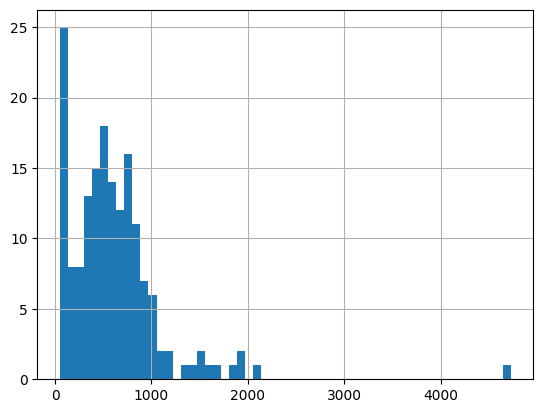

In [ ]:
df['tokens_number'].hist(bins=len(df) // 3)

In [ ]:
df.groupby('source')['tokens_number'].sum()

,tokens_number
source,
Acharyan_2021,2746
Atamanyan_2006,37530
Atamanyan_2012,31192
Atamanyan_2017,20103
Dagldiyan_2023,1253
Popovyan,9768


In [ ]:
sum(df['tokens_number'])

102592

In [ ]:
df.to_pickle('data.pkl')

### Export texts and metadata

In [9]:
def transliterate_MEA(text):

	from re import sub

	eanc = (('ու', 'u'), ('ւ', 'w'), ('ա', 'a'), ('բ', 'b'), ('գ', 'g'), ('դ', 'd'), ('ե', 'e'), ('զ', 'z'), ('է', 'ē'), ('ը', 'ə'), ('թ', 't‘'), ('ժ', 'ž'), ('ի', 'i'), ('լ', 'l'), ('խ', 'x'), ('ծ', 'c'), ('կ', 'k'), ('հ', 'h'), ('ձ', 'j'), ('ղ', 'ġ'), ('ճ', 'č'), ('մ', 'm'), ('յ', 'y'), ('ն', 'n'), ('շ', 'š'), ('ո', 'o'), ('չ', 'č‘'), ('պ', 'p'), ('ջ', 'ĵ'), ('ռ', 'ŕ'), ('ս', 's'), ('վ', 'v'), ('տ', 't'), ('ր', 'r'), ('ց', 'c‘'), ('փ', 'p‘'), ('ք', 'k‘'), ('օ', 'ō'), ('ֆ', 'f'), ('և', 'ew'))
	eanc_upper = (('ՈՒ', 'U'), ('Ու', 'U'), ('Ւ', 'W'), ('Ա', 'A'), ('Բ', 'B'), ('Գ', 'G'), ('Դ', 'D'), ('Ե', 'E'), ('Զ', 'Z'), ('Է', 'Ē'), ('Ը', 'Ə'), ('Թ', 'T‘'), ('Ժ', 'Ž'), ('Ի', 'I'), ('Լ', 'L'), ('Խ', 'X'), ('Ծ', 'C'), ('Կ', 'K'), ('Հ', 'H'), ('Ձ', 'J'), ('Ղ', 'Ġ'), ('Ճ', 'Č'), ('Մ', 'M'), ('Յ', 'Y'), ('Ն', 'N'), ('Շ', 'Š'), ('Ո', 'O'), ('Չ', 'Č‘'), ('Պ', 'P'), ('Ջ', 'Ĵ'), ('Ռ', 'Ŕ'), ('Ս', 'S'), ('Վ', 'V'), ('Տ', 'T'), ('Ր', 'R'), ('Ց', 'C‘'), ('Փ', 'P‘'), ('Ք', 'K‘'), ('Օ', 'Ō'), ('Ֆ', 'F'))
	# եւ is processed as two separate letters, as well as եվ

	result = text

	# firstly upper, otherwise Ու would produce wrong *ow
	for i in eanc_upper:
		result = sub(i[0], i[1], result)
	for i in eanc:
		result = sub(i[0], i[1], result)

	return result

In [3]:
df = pd.read_pickle('data.pkl')
df.head(3)

,title,text,date,source,genre,tokens_number
0,ԴՊՐՈՑԻ ՃԱՆՓԱՆ,ԴՊՐՈՑԻ ՃԱՆՓԱՆ \n(Թոփտիի խոսվածքով) \n\nԲուզլավ...,1968,Atamanyan_2006,poem,83
1,ՄԵՐ «ԸՆԿԵՐԸ»,"ՄԵՐ «ԸՆԿԵՐԸ» \n\nԴասարանին դուռը բացվեցավ, Երկ...",1999,Atamanyan_2006,poem,66
2,ՄԵՐ ԽԱՄՈՒԹԻ ՃԱՆՓԱՆ,ՄԵՐ ԽԱՄՈՒԹԻ ՃԱՆՓԱՆ \n(Թոփտիի խոսվածքով) \n\nՄե...,1971,Atamanyan_2006,poem,93


In [7]:
# make sure all titles are unique
df['title'].nunique() == len(df['title']) - 1

167

In [15]:
from pathlib import Path

with open('meta.csv', 'w', encoding='utf8') as f:

    f.write('filename\ttitle\tsource\tgenre\tdate\n', )

    for row in df.itertuples():

        title = transliterate_MEA(row.title).lower() + '.txt'
        text = row.text
        source = row.source

        source_dir = Path(source)
        source_dir.mkdir(parents=True, exist_ok=True)

        file_path = source_dir / title
        # file_path.write_text(text, encoding='utf-8')

        f.write(title + '\t' + row.title + '\t' + row.source \
                + '\t' + row.genre + '\t' + row.date + '\n')

In [17]:
pd.read_csv('meta.csv', sep='\t').head(3)

,filename,title,source,genre,date
0,dproc‘i čanp‘an.txt,ԴՊՐՈՑԻ ՃԱՆՓԱՆ,Atamanyan_2006,poem,1968.0
1,mer «ənkerə».txt,ՄԵՐ «ԸՆԿԵՐԸ»,Atamanyan_2006,poem,1999.0
2,mer xamut‘i čanp‘an.txt,ՄԵՐ ԽԱՄՈՒԹԻ ՃԱՆՓԱՆ,Atamanyan_2006,poem,1971.0


In [ ]:
!zip -r 'raw_texts.zip' 'Atamanyan_2006' 'Atamanyan_2012' 'Atamanyan_2017' 'Popovyan' 'Acharyan_2021' 'Dagldiyan_2023'

  adding: Atamanyan_2006/ (stored 0%)
  adding: Atamanyan_2006/ank‘aġak‘avarut‘yan vnasner.txt (deflated 65%)
  adding: Atamanyan_2006/vaŕuš ev maxtar mecanerus t‘it‘un caxacnerə.txt (deflated 67%)
  adding: Atamanyan_2006/anč‘ap‘ xmič‘k‘i hetevank‘ə.txt (deflated 65%)
  adding: Atamanyan_2006/gapŕelin čarə.txt (deflated 67%)
  adding: Atamanyan_2006/mer morak‘uyr yevkinen.txt (deflated 60%)
  adding: Atamanyan_2006/nikoġos ōštaxis darderə.txt (deflated 68%)
  adding: Atamanyan_2006/t‘op‘tin ev t‘op‘c‘ikə.txt (deflated 59%)
  adding: Atamanyan_2006/xaŕamanin k‘škorə.txt (deflated 64%)
  adding: Atamanyan_2006/mec pativi gaġtnik‘ə.txt (deflated 67%)
  adding: Atamanyan_2006/berber vašdanin patmacneric‘.txt (deflated 63%)
  adding: Atamanyan_2006/ōhanə.txt (deflated 57%)
  adding: Atamanyan_2006/k‘axc‘acin tarvan zenkinin xiġčə.txt (deflated 66%)
  adding: Atamanyan_2006/dibonĵi yangan.txt (deflated 58%)
  adding: Atamanyan_2006/hušarjanə.txt (deflated 54%)
  adding: Atamanyan_2006/patmu